# Notebook 1: Data Ingestion
## Mutual Fund Analytics Platform

This notebook handles data ingestion from raw CSV files and provides basic data overview.

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Directory Setup
Define paths to raw and processed data directories.

In [14]:
# Set paths
BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

print(f"Raw data directory: {RAW_DIR}")
print(f"Directory exists: {RAW_DIR.exists()}")
print(f"Processed directory: {PROCESSED_DIR}")

Raw data directory: c:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\data\raw
Directory exists: True
Processed directory: c:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\data\processed


## 2. File Discovery
List all CSV files in the raw data directory and display their sizes.

In [15]:
# List all CSV files
csv_files = list(RAW_DIR.glob('*.csv'))
print(f"Found {len(csv_files)} CSV files:")

file_info = []
for f in csv_files:
    size_kb = f.stat().st_size / 1024
    file_info.append({'name': f.name, 'size_kb': size_kb})
    print(f"  - {f.name}: {size_kb:.2f} KB")

file_df = pd.DataFrame(file_info)

Found 8 CSV files:
  - investor_transactions.csv: 284.10 KB
  - MF101_HDFC_Large_Cap_Fund.csv: 31.65 KB
  - MF102_SBI_Bluechip_Fund.csv: 30.26 KB
  - MF103_ICICI_Balanced_Advantage_Fund.csv: 36.77 KB
  - MF104_Axis_Small_Cap_Fund.csv: 31.65 KB
  - MF105_Kotak_Equity_Opportunities.csv: 34.20 KB
  - nav_history.csv: 185.64 KB
  - scheme_performance.csv: 0.42 KB


## 3. File Size Visualization
Visualize the size distribution of raw data files.

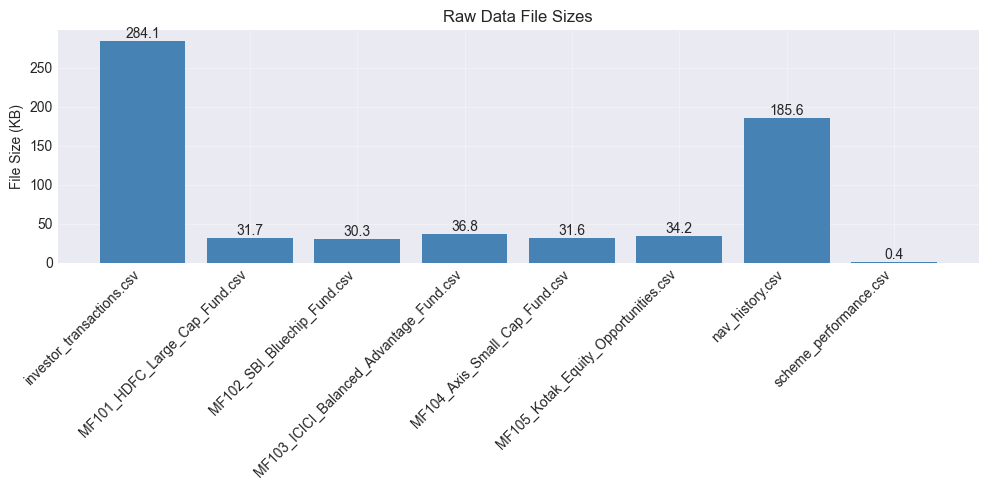

In [22]:
# Visualization: File sizes bar chart
if len(file_info) > 0:
    file_df = pd.DataFrame(file_info)

    plt.figure(figsize=(10, 5))
    bars = plt.bar(file_df["name"], file_df["size_kb"], color="steelblue")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("File Size (KB)")
    plt.title("Raw Data File Sizes")
    plt.grid(True, alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()
else:
    print("No CSV files found to visualize")

## 4. Data Loading & Preview
Load each CSV file and display basic information including shape, columns, and sample data.

In [23]:
# Load and preview each CSV
def load_and_preview(filepath):
    try:
        df = pd.read_csv(filepath)
        print(f"\n{'='*50}")
        print(f"File: {filepath.name}")
        print(f"{'='*50}")
        print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
        print(f"Columns: {list(df.columns)}")
        print(f"\nFirst 3 rows:")
        print(df.head(3))
        print(f"\nData types:")
        print(df.dtypes.value_counts())
        return df
    except Exception as e:
        print(f"Error loading {filepath.name}: {e}")
        return None


data_dict = {}
for csv_file in csv_files:
    df = load_and_preview(csv_file)
    if df is not None:
        data_dict[csv_file.stem] = df


File: investor_transactions.csv
Shape: 5,000 rows, 7 columns
Columns: ['amfi_code', 'kyc_status', 'transaction_type', 'amount', 'state', 'city', 'date']

First 3 rows:
   amfi_code kyc_status transaction_type  amount        state     city  \
0     100002   Verified          Lumpsum   50000        Delhi    Delhi   
1     100003   Verified              SIP    2000   Tamil Nadu  Chennai   
2     100005    Pending              SIP    1000  Maharashtra  Chennai   

         date  
0  2023-12-30  
1  2025-08-15  
2  2023-04-16  

Data types:
str      5
int64    2
Name: count, dtype: int64

File: MF101_HDFC_Large_Cap_Fund.csv
Shape: 523 rows, 5 columns
Columns: ['scheme_code', 'scheme_name', 'fund_house', 'date', 'nav']

First 3 rows:
  scheme_code          scheme_name        fund_house        date     nav
0       MF101  HDFC Large Cap Fund  HDFC Mutual Fund  2024-01-01  45.346
1       MF101  HDFC Large Cap Fund  HDFC Mutual Fund  2024-01-02  45.261
2       MF101  HDFC Large Cap Fund  HDFC M

In [18]:
# Load and display each CSV
def load_and_preview(filepath):
    df = pd.read_csv(filepath)
    print(f"\n{'='*50}")
    print(f"File: {filepath.name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"Columns: {list(df.columns)[:5]}...")
    print(f"\nFirst 3 rows:")
    print(df.head(3))
    return df

data_dict = {}
for csv_file in csv_files:
    try:
        data_dict[csv_file.stem] = load_and_preview(csv_file)
    except Exception as e:
        print(f"Error loading {csv_file.name}: {e}")


File: investor_transactions.csv
Shape: 5000 rows, 7 columns
Columns: ['amfi_code', 'kyc_status', 'transaction_type', 'amount', 'state']...

First 3 rows:
   amfi_code kyc_status transaction_type  amount        state     city  \
0     100002   Verified          Lumpsum   50000        Delhi    Delhi   
1     100003   Verified              SIP    2000   Tamil Nadu  Chennai   
2     100005    Pending              SIP    1000  Maharashtra  Chennai   

         date  
0  2023-12-30  
1  2025-08-15  
2  2023-04-16  

File: MF101_HDFC_Large_Cap_Fund.csv
Shape: 523 rows, 5 columns
Columns: ['scheme_code', 'scheme_name', 'fund_house', 'date', 'nav']...

First 3 rows:
  scheme_code          scheme_name        fund_house        date     nav
0       MF101  HDFC Large Cap Fund  HDFC Mutual Fund  2024-01-01  45.346
1       MF101  HDFC Large Cap Fund  HDFC Mutual Fund  2024-01-02  45.261
2       MF101  HDFC Large Cap Fund  HDFC Mutual Fund  2024-01-03  45.712

File: MF102_SBI_Bluechip_Fund.csv
Shape:

## 5. Data Summary
Summary table of all loaded datasets.

In [ ]:
# Summary table
print("\n" + "=" * 50)
print("DATA INGESTION SUMMARY")
print("=" * 50)

summary_data = []
for name, df in data_dict.items():
    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    summary_data.append(
        {
            "File": name,
            "Rows": f"{len(df):,}",
            "Columns": len(df.columns),
            "Memory (MB)": f"{memory_mb:.2f}",
        }
    )

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


DATA INGESTION SUMMARY
                               File  Rows  Columns Memory (MB)
              investor_transactions 5,000        7        0.46
          MF101_HDFC_Large_Cap_Fund   523        5        0.05
            MF102_SBI_Bluechip_Fund   523        5        0.04
MF103_ICICI_Balanced_Advantage_Fund   523        5        0.05
          MF104_Axis_Small_Cap_Fund   523        5        0.05
   MF105_Kotak_Equity_Opportunities   523        5        0.05
                        nav_history 3,915        4        0.24
                 scheme_performance     5        8        0.00


## 6. Records Visualization
Visualize the number of records in each file.

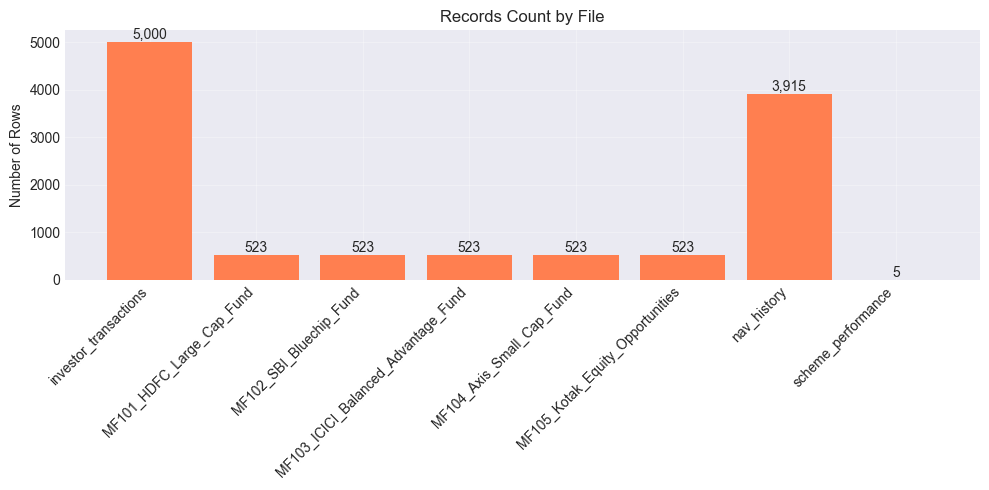

In [25]:
# Visualization: Records per file
if len(summary_data) > 0:
    summary_df["Rows_num"] = summary_df["Rows"].str.replace(",", "").astype(int)

    plt.figure(figsize=(10, 5))
    bars = plt.bar(summary_df["File"], summary_df["Rows_num"], color="coral")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of Rows")
    plt.title("Records Count by File")
    plt.grid(True, alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

## Data Ingestion Complete

✅ All raw CSV files have been successfully loaded.

**Files loaded:** {len(data_dict)}

### Next Steps
Proceed to **Notebook 2: Data Cleaning**